In [30]:
import pandas as pd 
data=pd.read_csv('loan.csv')
data.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [31]:
data.isna().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [32]:
categotrical=data.select_dtypes(include='object').columns

In [33]:
numerical=data.select_dtypes(include='number').columns

In [34]:
data[numerical]=data[numerical].fillna('method=ffill')

In [35]:
data[categotrical]=data[categotrical].fillna('method=ffill')

In [36]:
data.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

<Axes: xlabel='Education', ylabel='ApplicantIncome'>

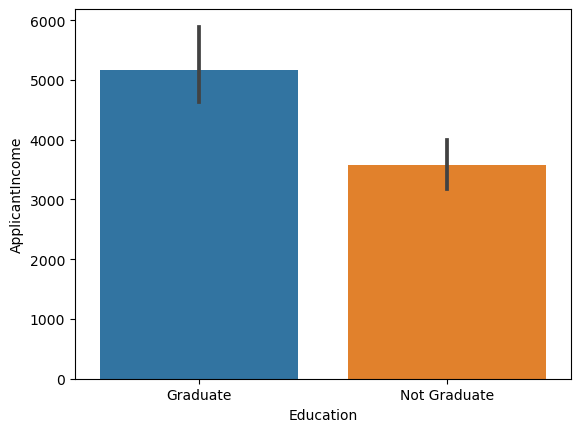

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot( data=data,x='Education',y='ApplicantIncome')

<Axes: xlabel='Property_Area', ylabel='ApplicantIncome'>

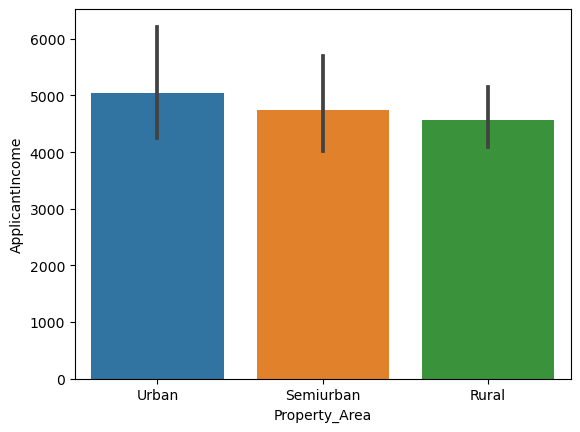

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(data=data,x='Property_Area',y='ApplicantIncome')

In [39]:
data.dtypes

Loan_ID              object
Gender               object
Married              object
Dependents           object
Education            object
Self_Employed        object
ApplicantIncome       int64
CoapplicantIncome     int64
LoanAmount           object
Loan_Amount_Term     object
Credit_History       object
Property_Area        object
dtype: object

In [43]:
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

In [55]:


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

data.replace('method=ffill', np.nan, inplace=True)


data = data.ffill()


for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = LabelEncoder().fit_transform(data[col].astype(str))

X = data.drop('Self_Employed', axis=1)
y = data['Self_Employed']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)



In [56]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [57]:

y_pred = model.predict(X_test)

In [58]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6756756756756757
